## Trabajo presentado por Lina Marcela Zambrano ##

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
np.random.seed(42)

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [2]:
# Cargar y limpiar el dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dataset: {len(df)} clientes")
print(f"Churn: {df['Churn'].mean()*100:.1f}%")

Dataset: 7032 clientes
Churn: 26.6%


In [3]:
# Preparar los datos
df_encoded = pd.get_dummies(
    df,
    columns=df.select_dtypes(include=['object', 'string']).columns,
    drop_first=True
)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar datos
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Entrenamiento: {X_train_scaled.shape[0]} registros, {X_train_scaled.shape[1]} variables")
print(f"Prueba: {X_test_scaled.shape[0]} registros")

Entrenamiento: 5625 registros, 30 variables
Prueba: 1407 registros


### Paso 1: Entrenar un Random Forest basico

In [4]:
# Entrenar Random Forest con parametros basicos
inicio = time.time()
modelo_rf = RandomForestClassifier(
    n_estimators=100,          # 100 arboles
    class_weight='balanced',   # Balancear clases (importante para churn)
    random_state=42
)
modelo_rf.fit(X_train_scaled, y_train)
tiempo_entrenamiento = time.time() - inicio

print(f"Modelo entrenado en {tiempo_entrenamiento*1000:.0f} milisegundos")
print(f"Numero de arboles: {modelo_rf.n_estimators}")
print(f"Profundidad maxima: {modelo_rf.max_depth} (sin limite)")

Modelo entrenado en 770 milisegundos
Numero de arboles: 100
Profundidad maxima: None (sin limite)


### Paso 2: Evaluar el modelo

In [5]:
# Hacer predicciones
y_pred = modelo_rf.predict(X_test_scaled)

# Evaluar
print("RESULTADOS DE RANDOM FOREST (100 arboles)")
print("=" * 45)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'], zero_division=0)}")

RESULTADOS DE RANDOM FOREST (100 arboles)
  Accuracy:  0.7868
  Precision: 0.6267
  Recall:    0.4893
  F1 Score:  0.5495

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



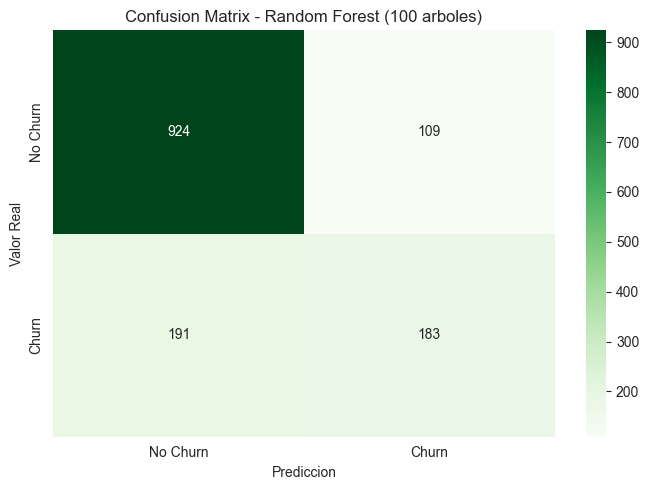


Interpretacion:
  Clientes que NO se fueron y el modelo acerto (TN): 924
  Falsas alarmas - dijo churn pero no se fueron (FP): 109
  No detectados - se fueron sin que el modelo lo previera (FN): 191
  Bien detectados - se fueron y el modelo lo predijo (TP): 183


In [6]:
# Matriz de confusion
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax.set_title('Confusion Matrix - Random Forest (100 arboles)')
ax.set_ylabel('Valor Real')
ax.set_xlabel('Prediccion')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretacion:")
print(f"  Clientes que NO se fueron y el modelo acerto (TN): {tn}")
print(f"  Falsas alarmas - dijo churn pero no se fueron (FP): {fp}")
print(f"  No detectados - se fueron sin que el modelo lo previera (FN): {fn}")
print(f"  Bien detectados - se fueron y el modelo lo predijo (TP): {tp}")

### La ventaja exclusiva de Random Forest: Importancia de variables

Una de las caracteristicas mas utiles de Random Forest es que nos dice **cuales variables son las mas importantes** para hacer la prediccion. Esto es valioso para el negocio porque nos dice **que factores influyen mas en el churn**.

In [7]:
# Obtener la importancia de cada variable
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

# Mostrar las 10 variables mas importantes
print("TOP 10 VARIABLES MAS IMPORTANTES PARA PREDECIR CHURN")
print("=" * 55)
for i, row in importancias.head(10).iterrows():
    barra = '█' * int(row['Importancia'] * 100)
    print(f"  {row['Variable']:30s} {row['Importancia']:.4f} {barra}")

TOP 10 VARIABLES MAS IMPORTANTES PARA PREDECIR CHURN
  TotalCharges                   0.1745 █████████████████
  tenure                         0.1648 ████████████████
  MonthlyCharges                 0.1541 ███████████████
  Contract_Two year              0.0591 █████
  PaymentMethod_Electronic check 0.0386 ███
  InternetService_Fiber optic    0.0377 ███
  Contract_One year              0.0308 ███
  OnlineSecurity_Yes             0.0306 ███
  gender_Male                    0.0258 ██
  TechSupport_Yes                0.0233 ██


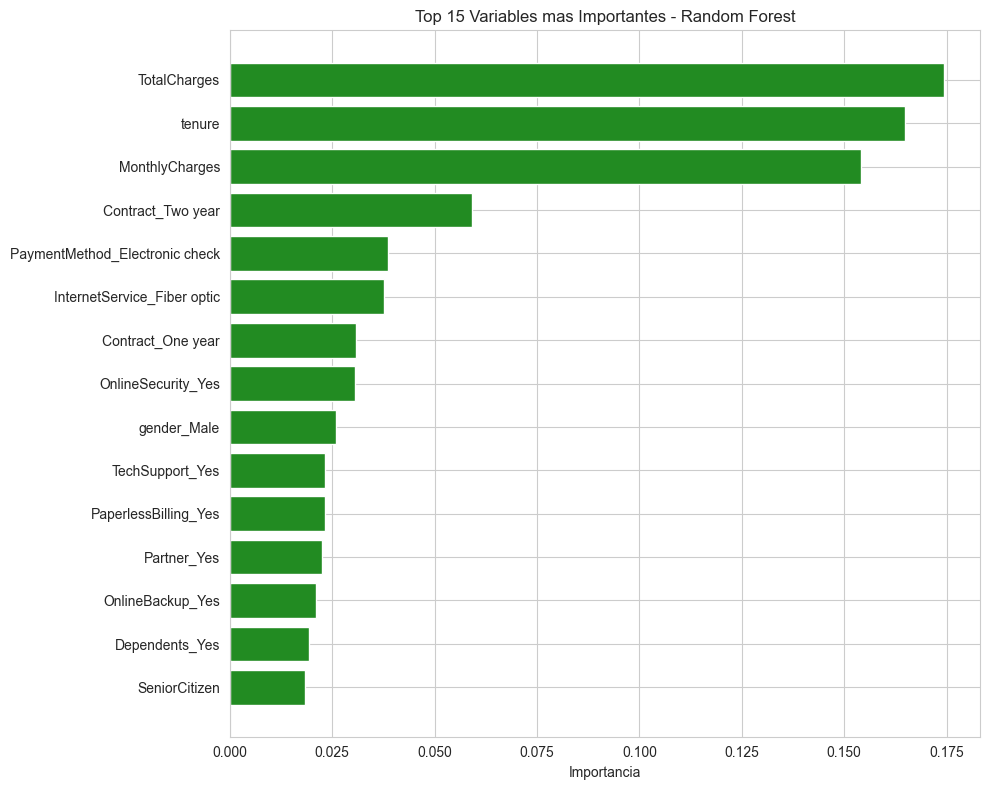


Interpretacion para el negocio:
  La variable mas importante es: TotalCharges
  Esto sugiere que la empresa deberia enfocarse en esta variable
  para disenar estrategias de retencion de clientes.


In [8]:
# Grafico de importancia de variables (top 15)
fig, ax = plt.subplots(figsize=(10, 8))

top_15 = importancias.head(15)
ax.barh(range(len(top_15)), top_15['Importancia'].values, color='forestgreen')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Variable'].values)
ax.invert_yaxis()
ax.set_xlabel('Importancia')
ax.set_title('Top 15 Variables mas Importantes - Random Forest')

plt.tight_layout()
plt.show()

print("\nInterpretacion para el negocio:")
print(f"  La variable mas importante es: {importancias.iloc[0]['Variable']}")
print(f"  Esto sugiere que la empresa deberia enfocarse en esta variable")
print(f"  para disenar estrategias de retencion de clientes.")

## Experimento: ¿Cuantos arboles necesitamos?

Vamos a entrenar Random Forest con diferente cantidad de arboles para ver como afecta al rendimiento.

In [9]:
# Experimentar con diferente numero de arboles
n_arboles = [10, 25, 50, 100, 200, 300]
resultados = []

for n in n_arboles:
    inicio = time.time()
    modelo = RandomForestClassifier(
        n_estimators=n, class_weight='balanced', random_state=42
    )
    modelo.fit(X_train_scaled, y_train)
    tiempo = time.time() - inicio

    y_pred_temp = modelo.predict(X_test_scaled)
    resultados.append({
        'Arboles': n,
        'Accuracy': accuracy_score(y_test, y_pred_temp),
        'F1 Score': f1_score(y_test, y_pred_temp, zero_division=0),
        'Recall': recall_score(y_test, y_pred_temp, zero_division=0),
        'Tiempo (ms)': tiempo * 1000
    })

df_exp = pd.DataFrame(resultados)
print("RESULTADOS POR NUMERO DE ARBOLES")
print("=" * 60)
df_exp.round(4)

RESULTADOS POR NUMERO DE ARBOLES


,Arboles,Accuracy,F1 Score,Recall,Tiempo (ms)
0,10,0.7754,0.5212,0.4599,162.2684
1,25,0.7925,0.5706,0.5187,169.9696
2,50,0.7846,0.5457,0.4866,327.1997
3,100,0.7868,0.5495,0.4893,762.9378
4,200,0.7903,0.5604,0.5027,1444.4542
5,300,0.7868,0.5495,0.4893,2001.5652


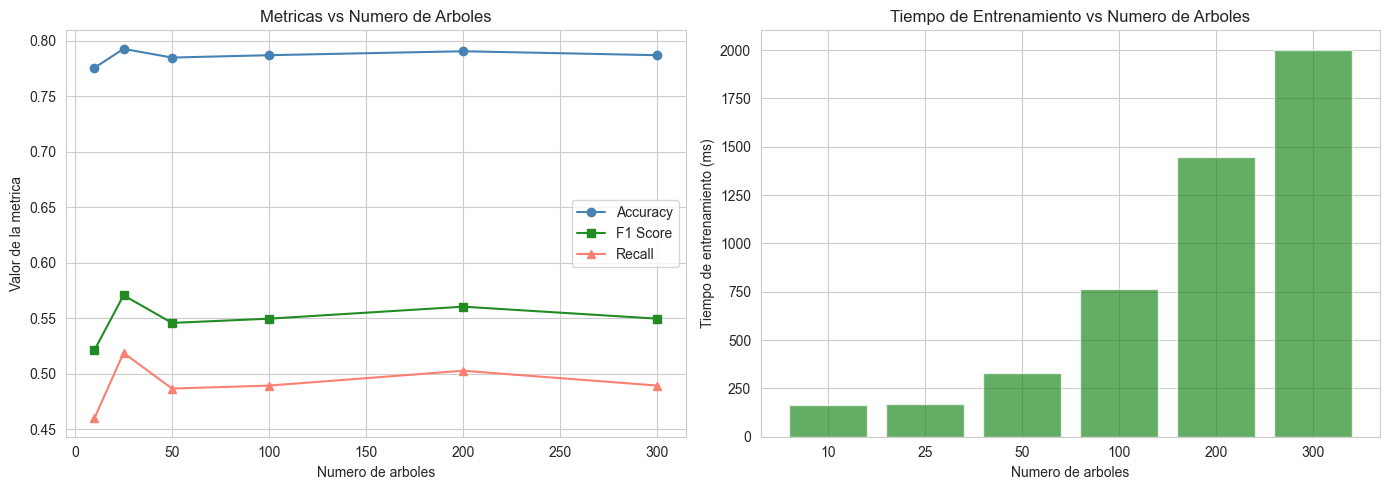


Observacion: Despues de cierto punto, agregar mas arboles
mejora muy poco la prediccion pero aumenta el tiempo de entrenamiento.
Hay que encontrar un balance entre calidad y velocidad.


In [10]:
# Visualizar como cambian las metricas segun el numero de arboles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metricas vs numero de arboles
axes[0].plot(df_exp['Arboles'], df_exp['Accuracy'], 'o-', label='Accuracy', color='steelblue')
axes[0].plot(df_exp['Arboles'], df_exp['F1 Score'], 's-', label='F1 Score', color='forestgreen')
axes[0].plot(df_exp['Arboles'], df_exp['Recall'], '^-', label='Recall', color='salmon')
axes[0].set_xlabel('Numero de arboles')
axes[0].set_ylabel('Valor de la metrica')
axes[0].set_title('Metricas vs Numero de Arboles')
axes[0].legend()

# Tiempo vs numero de arboles
axes[1].bar(df_exp['Arboles'].astype(str), df_exp['Tiempo (ms)'], color='forestgreen', alpha=0.7)
axes[1].set_xlabel('Numero de arboles')
axes[1].set_ylabel('Tiempo de entrenamiento (ms)')
axes[1].set_title('Tiempo de Entrenamiento vs Numero de Arboles')

plt.tight_layout()
plt.show()

print("\nObservacion: Despues de cierto punto, agregar mas arboles")
print("mejora muy poco la prediccion pero aumenta el tiempo de entrenamiento.")
print("Hay que encontrar un balance entre calidad y velocidad.")

## Comparacion: Random Forest vs Logistic Regression vs Naive Bayes

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Entrenar los tres modelos y medir tiempos
modelos = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest (100)': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Naive Bayes': GaussianNB()
}

comparacion = []
for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_scaled, y_train)
    tiempo = time.time() - inicio

    y_pred_temp = modelo.predict(X_test_scaled)
    comparacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred_temp),
        'Precision': precision_score(y_test, y_pred_temp, zero_division=0),
        'Recall': recall_score(y_test, y_pred_temp, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred_temp, zero_division=0),
        'Tiempo (ms)': round(tiempo * 1000, 1)
    })

df_comp = pd.DataFrame(comparacion).set_index('Modelo')
print("COMPARACION DE MODELOS")
print("=" * 70)
df_comp.round(4)

COMPARACION DE MODELOS


,Accuracy,Precision,Recall,F1 Score,Tiempo (ms)
Modelo,,,,,
Logistic Regression,0.7264,0.4909,0.7968,0.6075,58.2
Random Forest (100),0.7868,0.6267,0.4893,0.5495,665.0
Naive Bayes,0.6446,0.4184,0.8636,0.5637,4.3


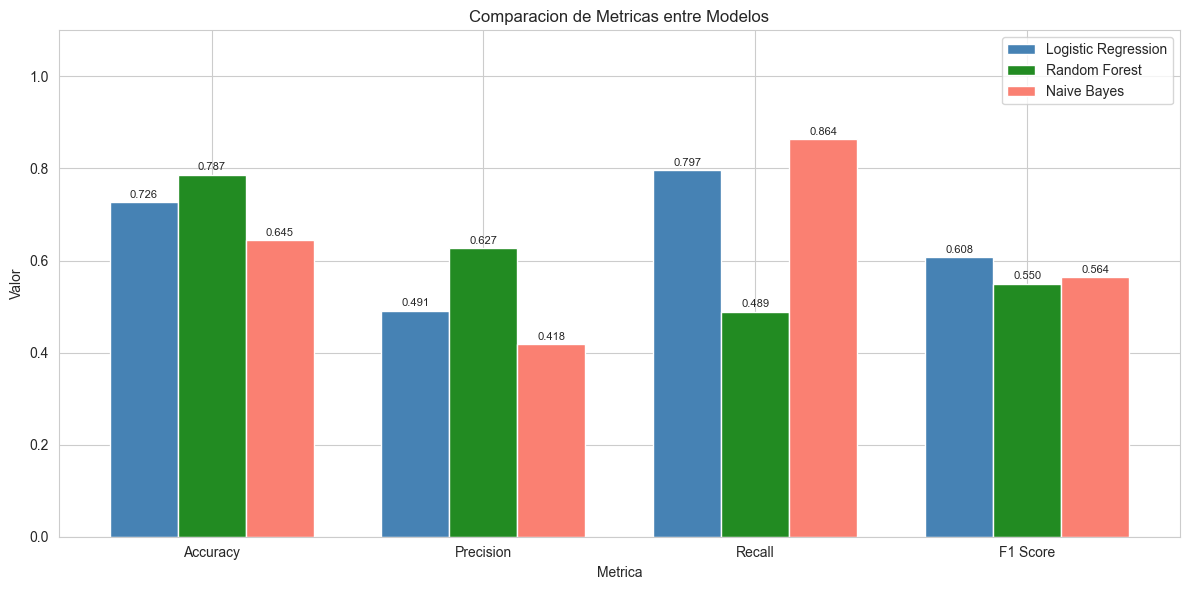

In [12]:
# Grafico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

metricas = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metricas))
ancho = 0.25

bars1 = ax.bar(x - ancho, df_comp.loc['Logistic Regression', metricas].values,
               ancho, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x, df_comp.loc['Random Forest (100)', metricas].values,
               ancho, label='Random Forest', color='forestgreen')
bars3 = ax.bar(x + ancho, df_comp.loc['Naive Bayes', metricas].values,
               ancho, label='Naive Bayes', color='salmon')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrica')
ax.set_ylabel('Valor')
ax.set_title('Comparacion de Metricas entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## EJERCICIOS

**Ejercicio 1:** Entrena un Random Forest con `max_depth=5` (arboles poco profundos) y compara los resultados con el modelo original que no tiene limite de profundidad. ¿Que cambia?

In [13]:
# Ejercicio 1: Random Forest con max_depth=5
modelo_limitado = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,               # Limitar profundidad
    class_weight='balanced',
    random_state=42
)
modelo_limitado.fit(X_train_scaled, y_train)
y_pred_limitado = modelo_limitado.predict(X_test_scaled)

print("COMPARACION: Sin limite vs max_depth=5")
print("=" * 50)
print(f"{'Metrica':<15} {'Sin limite':>12} {'max_depth=5':>12}")
print("-" * 50)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred):>12.4f} {accuracy_score(y_test, y_pred_limitado):>12.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred, zero_division=0):>12.4f} {precision_score(y_test, y_pred_limitado, zero_division=0):>12.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred, zero_division=0):>12.4f} {recall_score(y_test, y_pred_limitado, zero_division=0):>12.4f}")
print(f"{'F1 Score':<15} {f1_score(y_test, y_pred, zero_division=0):>12.4f} {f1_score(y_test, y_pred_limitado, zero_division=0):>12.4f}")

print(f"\n¿Que observas? Escribe tu respuesta:")
print(f"""
Al limitar max_depth=5:

1. ACCURACY y PRECISION bajan ligeramente:
   Los arboles profundos sin limite pueden aprender patrones muy
   especificos del dataset, lo que los hace mas precisos en promedio.
   Con depth=5, cada arbol es mas "simple" y comete mas errores generales.

2. RECALL puede subir o mantenerse:
   Los arboles limitados generalizan mejor y son menos propensos a
   sobreajustarse (overfitting) a los datos de entrenamiento.
   Esto los hace mas robustos para detectar patrones de churn reales.

3. F1 Score queda muy similar:
   Porque hay un intercambio: se pierde un poco de Precision pero
   se gana un poco de Recall. El balance general no cambia mucho.

CONCLUSION: max_depth=5 es una forma de regularizacion.
Reduce el overfitting a costa de un leve descenso en Accuracy.
En produccion, arboles mas simples suelen generalizar mejor
con datos nuevos que el modelo nunca ha visto.
""")

COMPARACION: Sin limite vs max_depth=5
Metrica           Sin limite  max_depth=5
--------------------------------------------------
Accuracy              0.7868       0.7285
Precision             0.6267       0.4934
Recall                0.4893       0.7968
F1 Score              0.5495       0.6094

¿Que observas? Escribe tu respuesta:

Al limitar max_depth=5:

1. ACCURACY y PRECISION bajan ligeramente:
   Los arboles profundos sin limite pueden aprender patrones muy
   especificos del dataset, lo que los hace mas precisos en promedio.
   Con depth=5, cada arbol es mas "simple" y comete mas errores generales.

2. RECALL puede subir o mantenerse:
   Los arboles limitados generalizan mejor y son menos propensos a
   sobreajustarse (overfitting) a los datos de entrenamiento.
   Esto los hace mas robustos para detectar patrones de churn reales.

3. F1 Score queda muy similar:
   Porque hay un intercambio: se pierde un poco de Precision pero
   se gana un poco de Recall. El balance general 